# **WEEK 2 - KNOW YOUR DATA**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

# Upload file from your computer
uploaded = files.upload()

# Read the uploaded file
df = pd.read_csv('2017_dataset.csv')
print(df.info())
print(df.describe())
#To understand the data

TypeError: 'NoneType' object is not subscriptable

# **WEEK 3 - THE CLEANING SPRINT**

MISSING VALUES DETECTION:


MISSING VALUES DETECTION
Columns with missing values:
             Column  Missing_Count
        Unnamed: 27         200000
  CANCELLATION_CODE         197103
      CARRIER_DELAY         163716
LATE_AIRCRAFT_DELAY         163716
          NAS_DELAY         163716
      WEATHER_DELAY         163716
     SECURITY_DELAY         163716
ACTUAL_ELAPSED_TIME           3332
          ARR_DELAY           3332
           AIR_TIME           3332
            TAXI_IN           2968
           ARR_TIME           2968
          WHEELS_ON           2968
         WHEELS_OFF           2879
           TAXI_OUT           2879
          DEP_DELAY           2808
           DEP_TIME           2807




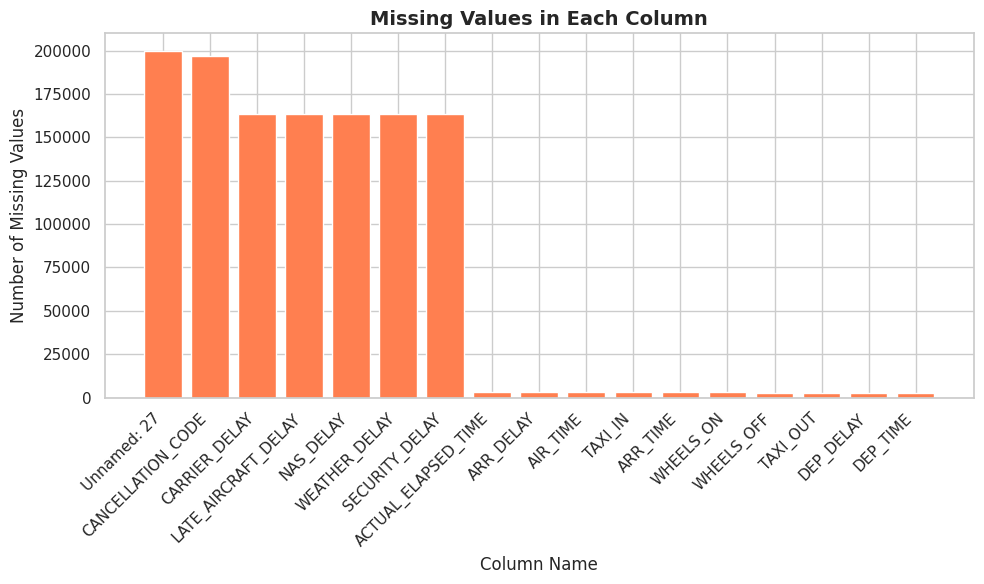

In [ ]:
print("MISSING VALUES DETECTION")

# Count missing values in each column
missing_count = df.isnull().sum()

# Create summary table
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': missing_count.values,
})

# Filter to show only columns with missing values
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]
missing_summary = missing_summary.sort_values('Missing_Count', ascending=False)

# Print columns with missing values
if len(missing_summary) > 0:
    print("Columns with missing values:")
    print(missing_summary.to_string(index=False))
    print("\n")

    # Visualize missing values with bar chart
    plt.figure(figsize=(10, 6))
    plt.bar(missing_summary['Column'], missing_summary['Missing_Count'], color='coral')
    plt.xlabel('Column Name', fontsize=12)
    plt.ylabel('Number of Missing Values', fontsize=12)
    plt.title('Missing Values in Each Column', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("✓ No missing values found in the dataset!")
    print("\n")


HANLDING MISSING VALUES:

In [14]:
print("HANDLING MISSING VALUES")
print("\n")

# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Handling NUMERIC columns:")
for col in numeric_cols:
    missing = df[col].isnull().sum()
    if missing > 0:
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)
        print(f"  ✓ {col}: Filled {missing} missing values with Median = {median_value:.2f}")

if not any(df[col].isnull().sum() > 0 for col in numeric_cols):
    print("  (No missing values in numeric columns)")

print("\nHandling CATEGORICAL columns:")
for col in categorical_cols:
    missing = df[col].isnull().sum()
    if missing > 0:
        mode_value = df[col].mode()[0]
        df[col] = df[col].fillna(mode_value)
        print(f"  ✓ {col}: Filled {missing} missing values with MODE = '{mode_value}'")

if not any(df[col].isnull().sum() > 0 for col in categorical_cols):
    print("  (No missing values in categorical columns)")

print("\n All missing values have been handled!")


HANDLING MISSING VALUES


Handling NUMERIC columns:
  ✓ Unnamed: 27: Filled 200000 missing values with Median = nan

Handling CATEGORICAL columns:
  (No missing values in categorical columns)

 All missing values have been handled!


OUTLIER DETECTION:

 Outliers are extreme values that differ significantly from the majority of the data and can distort analysis results.
 The Z-score method is used to identify such values so their impact can be examined and handled if necessary.

OUTLIER DETECTION
Columns being checked for outliers:
  • DEP_DELAY
  • ARR_DELAY
  • DISTANCE
  • AIR_TIME
  • TAXI_OUT
  • TAXI_IN


OUTLIER DETECTION RESULTS


Outliers detected in 6 column(s):

  • DEP_DELAY: 3,341 outliers (1.67%)
  • ARR_DELAY: 3,261 outliers (1.63%)
  • DISTANCE: 713 outliers (0.36%)
  • AIR_TIME: 2,084 outliers (1.04%)
  • TAXI_OUT: 3,502 outliers (1.75%)
  • TAXI_IN: 3,910 outliers (1.96%)




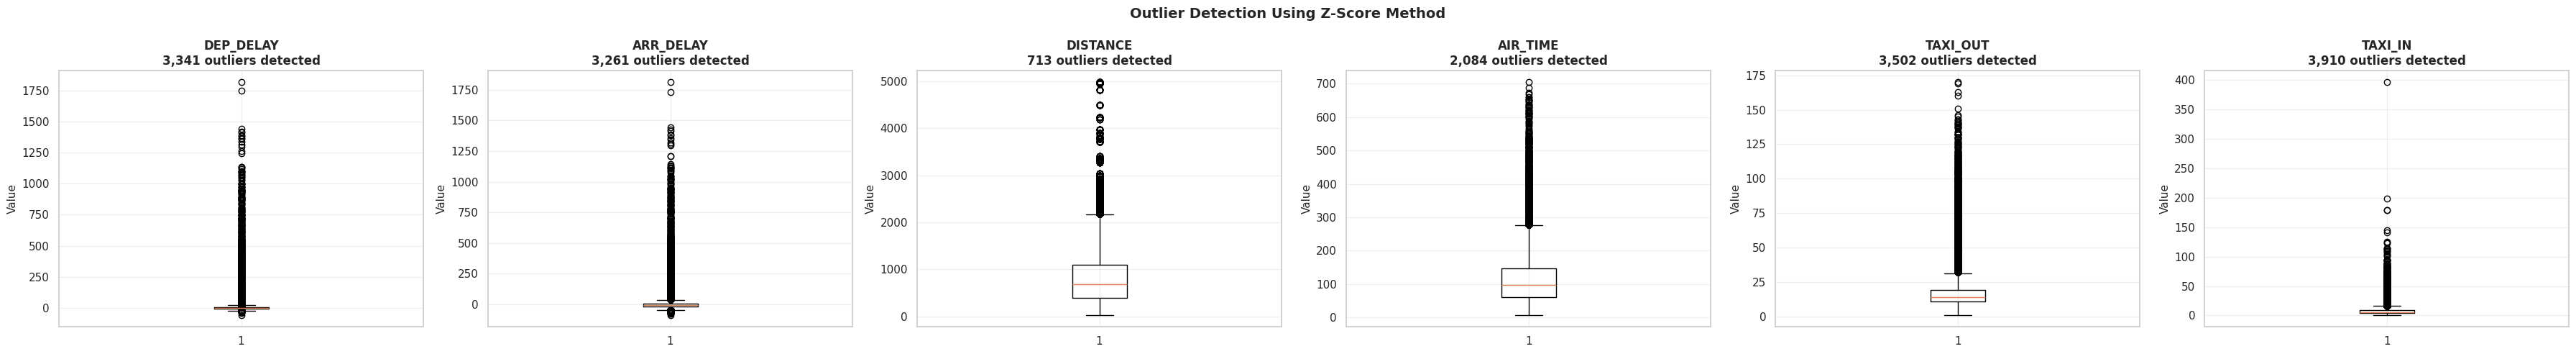

In [ ]:
print("OUTLIER DETECTION")

columns_to_check = [
    'DEP_DELAY',
    'ARR_DELAY',
    'DISTANCE',
    'AIR_TIME',
    'TAXI_OUT',
    'TAXI_IN'
]

columns_to_check = [col for col in columns_to_check if col in df.columns]

if len(columns_to_check) == 0:
    print("⚠ No columns found for outlier detection.")
    print("Please check if column names are correct!")
    print("\nActual numeric columns available in dataset:")
    print(df.select_dtypes(include=[np.number]).columns.tolist())
else:
    print("Columns being checked for outliers:")
    for col in columns_to_check:
        print(f"  • {col}")
    print("\n")

    # Store which columns have outliers
    columns_with_outliers = []
    outlier_info = {}

    for col in columns_to_check:
        # Remove missing values
        clean_data = df[col].dropna()

        # Calculate Z-scores manually
        mean = clean_data.mean()
        std = clean_data.std()
        z_scores = np.abs((clean_data - mean) / std)

        # Find outliers (Z-score > 3)
        outliers = z_scores > 3
        outlier_count = outliers.sum()
        outlier_percent = (outlier_count / len(clean_data)) * 100

        # If outliers exist, add to list
        if outlier_count > 0:
            columns_with_outliers.append(col)
            outlier_info[col] = {
                'count': outlier_count,
                'percent': outlier_percent
            }

print("OUTLIER DETECTION RESULTS")
print("\n")
if len(columns_with_outliers) > 0:
        print(f"Outliers detected in {len(columns_with_outliers)} column(s):\n")
        for col in columns_with_outliers:
            info = outlier_info[col]
            print(f"  • {col}: {info['count']:,} outliers ({info['percent']:.2f}%)")
        print("\n")

        num_cols = len(columns_with_outliers)
        fig, axes = plt.subplots(1, num_cols, figsize=(6 * num_cols, 5))

        # Handle case where there's only one column
        if num_cols == 1:
            axes = [axes]

        for i, col in enumerate(columns_with_outliers):
            # Create boxplot
            axes[i].boxplot(df[col].dropna(), vert=True)
            axes[i].set_title(f'{col}\n{outlier_info[col]["count"]:,} outliers detected',
                             fontsize=12, fontweight='bold')
            axes[i].set_ylabel('Value', fontsize=11)
            axes[i].grid(True, alpha=0.3)

        plt.suptitle('Outlier Detection Using Z-Score Method', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

else:
        print("✓ No outliers detected in any column!")
        print("(Using Z-score method with threshold > 3)")




### OUTLIER HANDLING:

Fixed DEP_DELAY:
  • Lower Limit: -21.50
  • Upper Limit: 22.50

Fixed ARR_DELAY:
  • Lower Limit: -45.50
  • Upper Limit: 38.50

Fixed DISTANCE:
  • Lower Limit: -680.00
  • Upper Limit: 2176.00

Fixed AIR_TIME:
  • Lower Limit: -67.00
  • Upper Limit: 277.00

Fixed TAXI_OUT:
  • Lower Limit: -1.00
  • Upper Limit: 31.00

Fixed TAXI_IN:
  • Lower Limit: -3.50
  • Upper Limit: 16.50



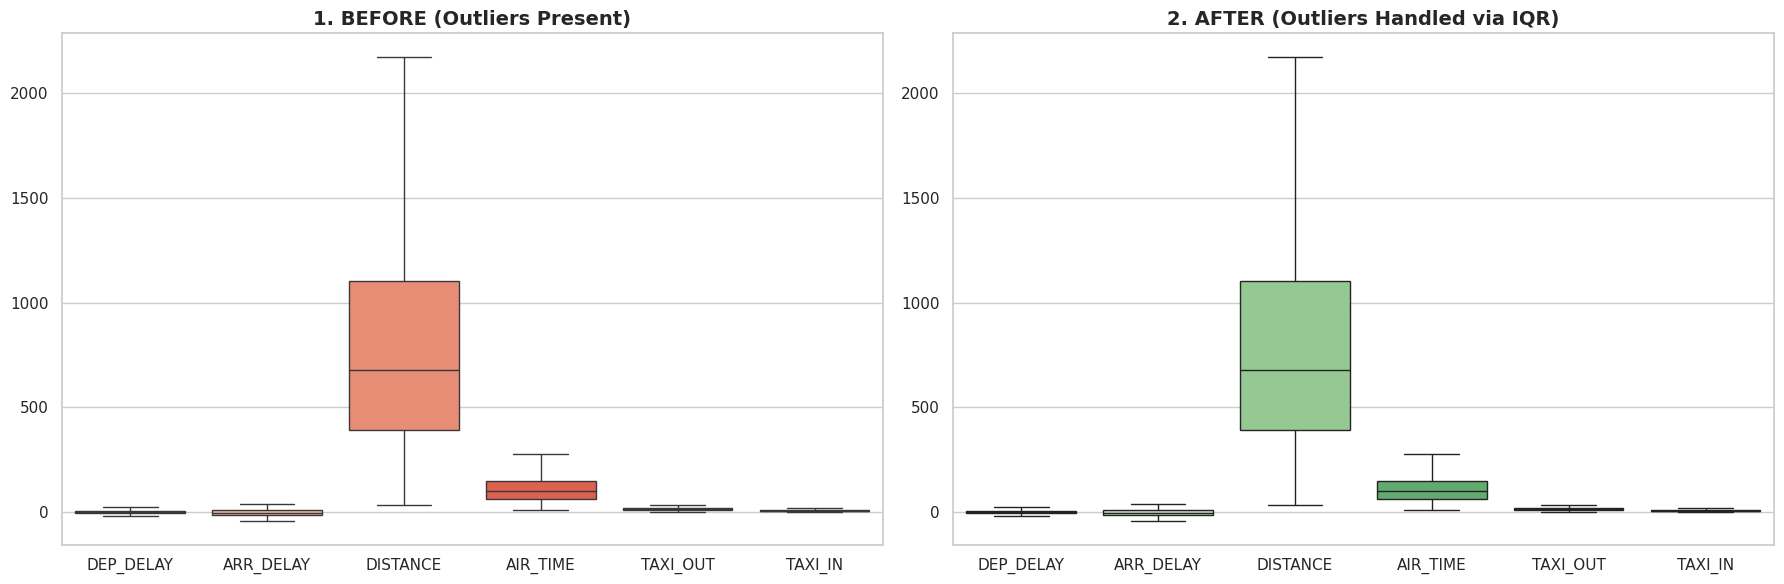

✓ DONE! Final file 'final_cleaned_dataset.csv' saved with all missing values and outliers handled.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
columns_to_fix = ['DEP_DELAY', 'ARR_DELAY', 'DISTANCE', 'AIR_TIME', 'TAXI_OUT', 'TAXI_IN']
columns_to_fix = [col for col in columns_to_fix if col in df.columns]

# Create a copy of the DataFrame BEFORE handling outliers for comparison
df_before_outliers = df.copy()

# 2. Loop through and handle outliers
for col in columns_to_fix:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Define the 'Whisker' boundaries (Standard for Boxplots)
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Cap the values in the ORIGINAL df
    df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

    print(f"Fixed {col}:")
    print(f"  • Lower Limit: {lower_limit:.2f}")
    print(f"  • Upper Limit: {upper_limit:.2f}\n")

# 3. VISUALIZATION: Before vs. After
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot Before (Has outliers)
sns.boxplot(data=df_before_outliers[columns_to_fix], ax=axes[0], palette="Reds")
axes[0].set_title("1. BEFORE (Outliers Present)", fontsize=14, fontweight='bold')

# Plot After (Outliers handled)
sns.boxplot(data=df[columns_to_fix], ax=axes[1], palette="Greens")
axes[1].set_title("2. AFTER (Outliers Handled via IQR)", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# 4. SAVE THE FINAL FILE
# This file now contains both your Missing Value fixes AND your Outlier fixes
file_name = "final_cleaned_dataset.csv"
df.to_csv(file_name, index=False)

print(f"✓ DONE! Final file '{file_name}' saved with all missing values and outliers handled.")

# 5. Download to your computer
files.download(file_name)

# WEEK 4 - DEEP DIVE IN EDA


Shape of Dataset: (200000, 28)

Columns:
 Index(['FL_DATE', 'OP_CARRIER', 'OP_CARRIER_FL_NUM', 'ORIGIN', 'DEST',
       'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY',
       'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME',
       'ACTUAL_ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'CARRIER_DELAY',
       'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY',
       'Unnamed: 27'],
      dtype='object')

Missing Values:
 FL_DATE                     0
OP_CARRIER                  0
OP_CARRIER_FL_NUM           0
ORIGIN                      0
DEST                        0
CRS_DEP_TIME                0
DEP_TIME                    0
DEP_DELAY                   0
TAXI_OUT                    0
WHEELS_OFF                  0
WHEELS_ON                   0
TAXI_IN                     0
CRS_ARR_TIME                0
ARR_TIME                    0
ARR_DELAY                   0
CANCE

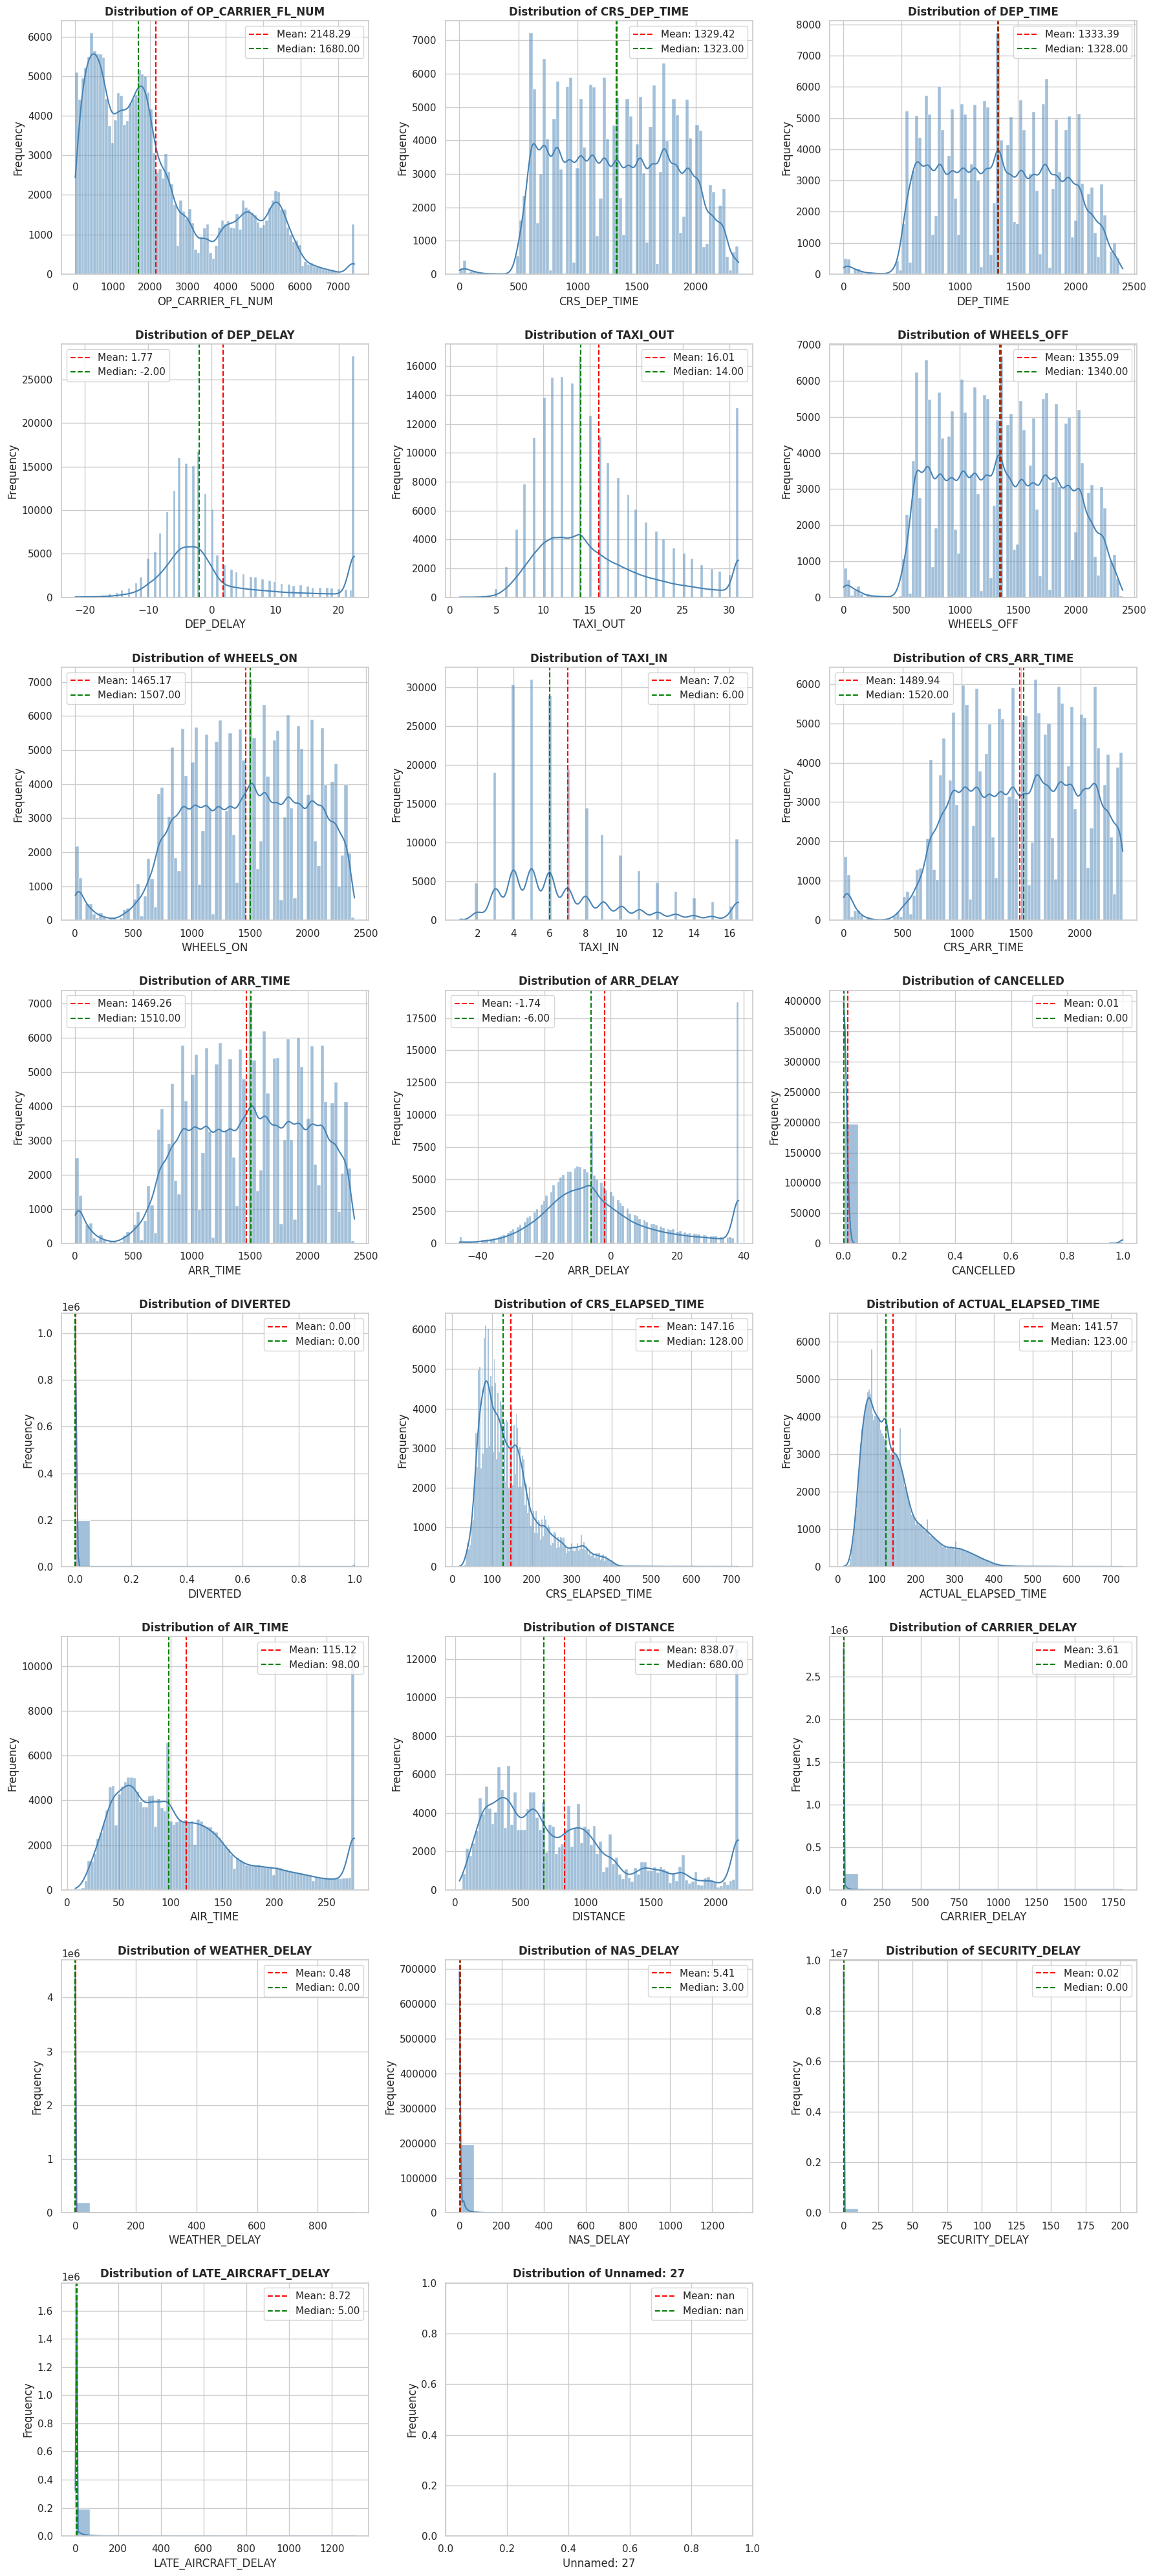

✓ Histograms created!

Creating Boxplots...
  ⚠ Skipping boxplot for Unnamed: 27: No valid data to plot after dropping NaNs.


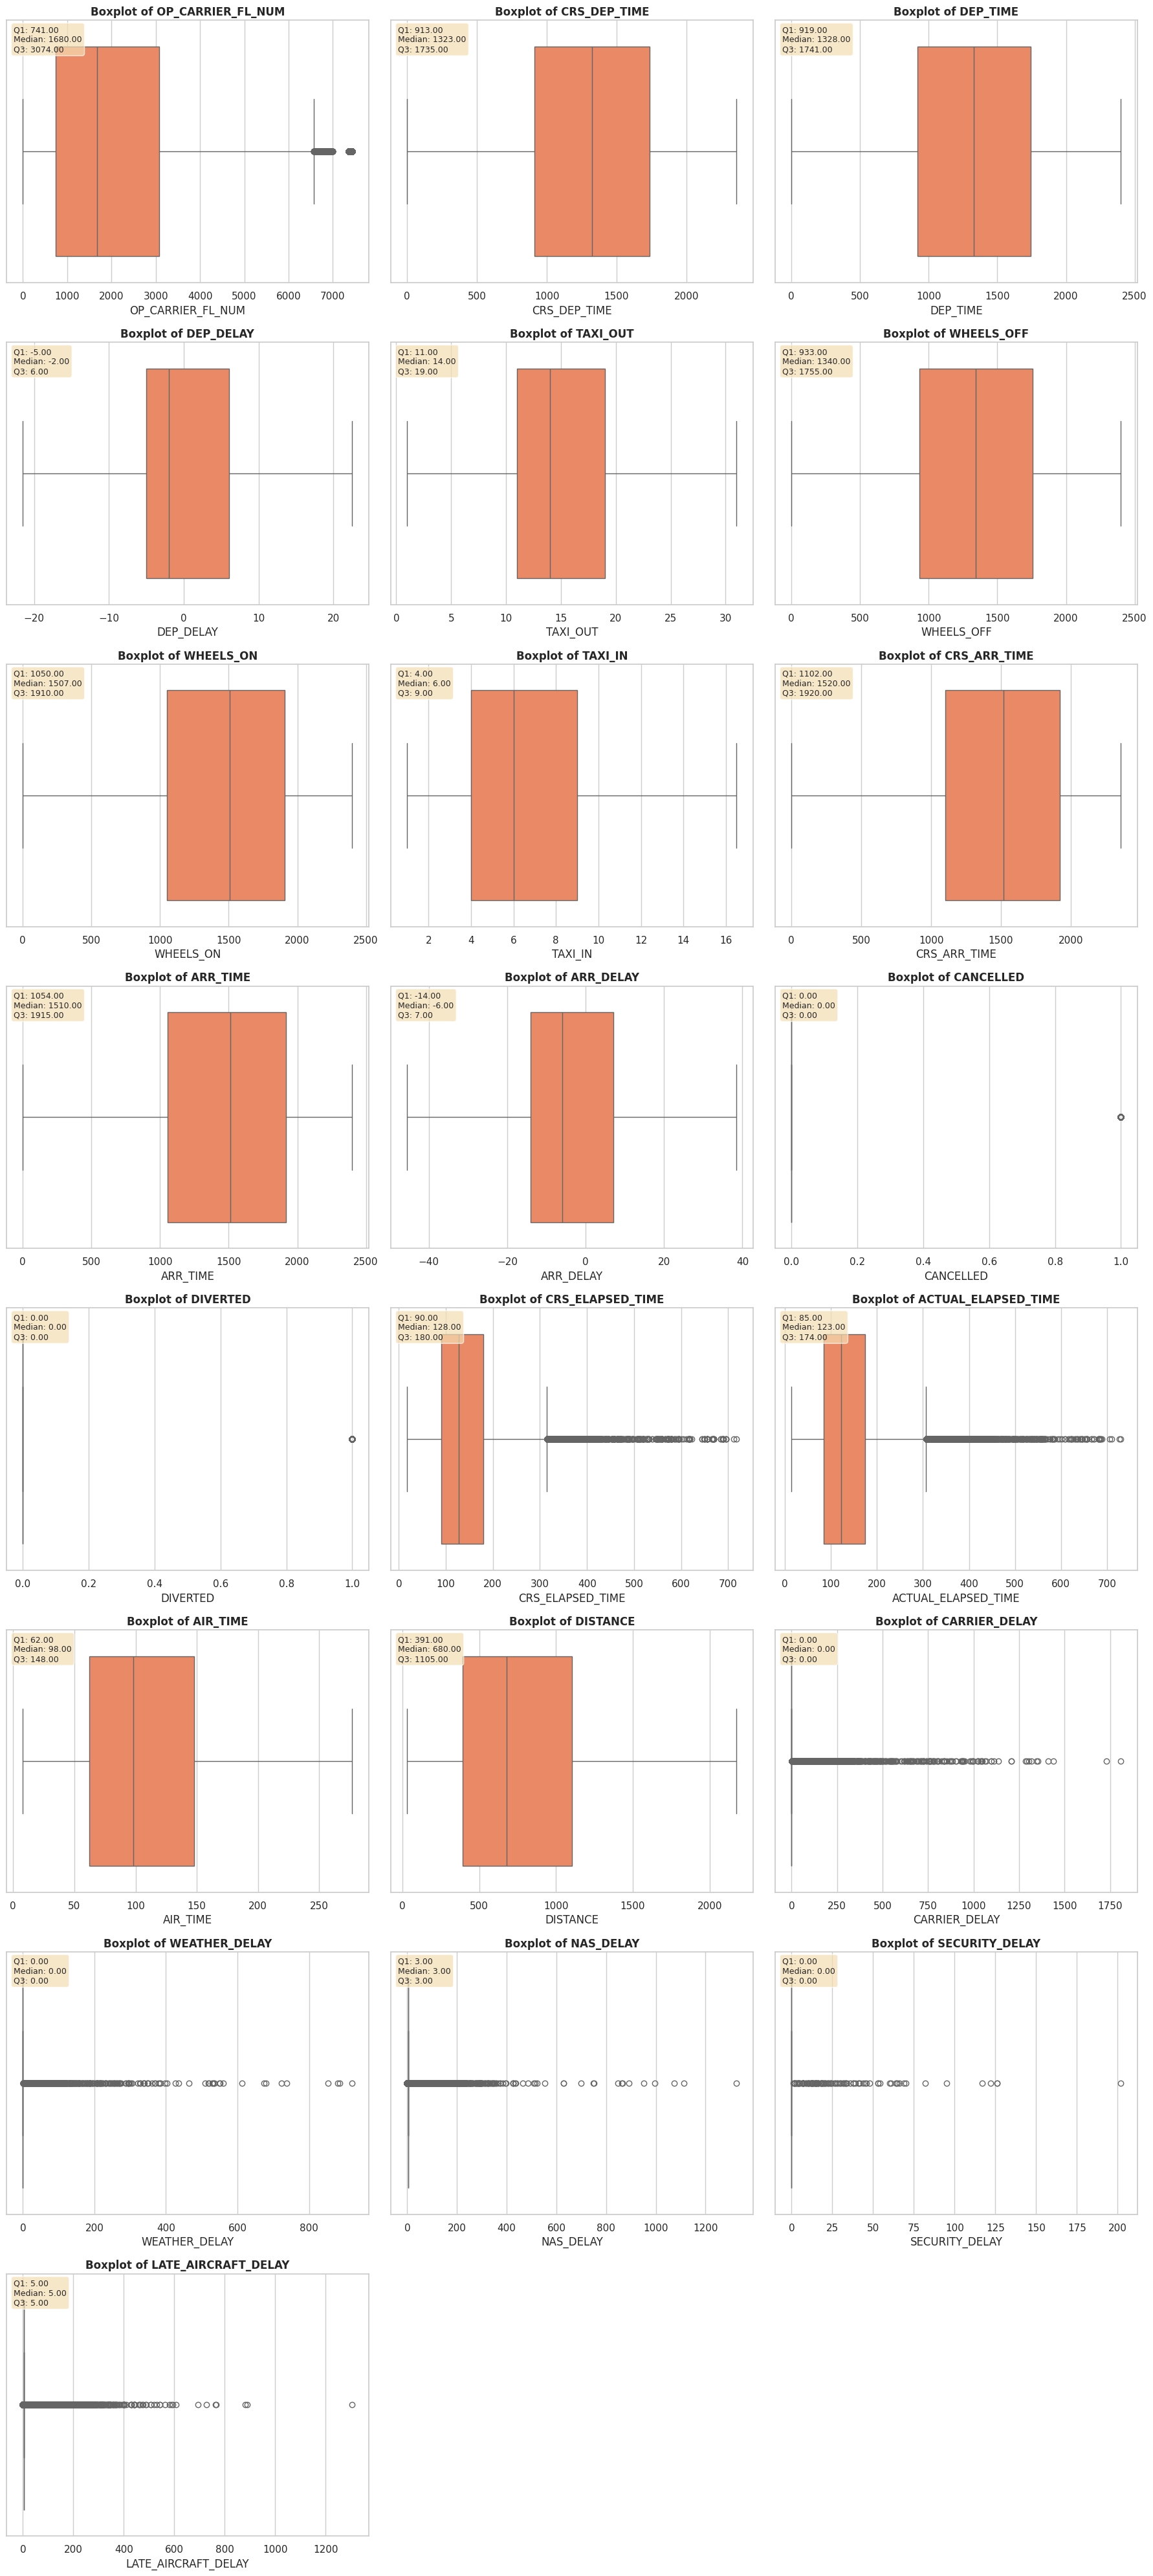

✓ Boxplots created!

✅ Univariate Analysis Completed!
BIVARIATE ANALYSIS

Creating Correlation Heatmap...


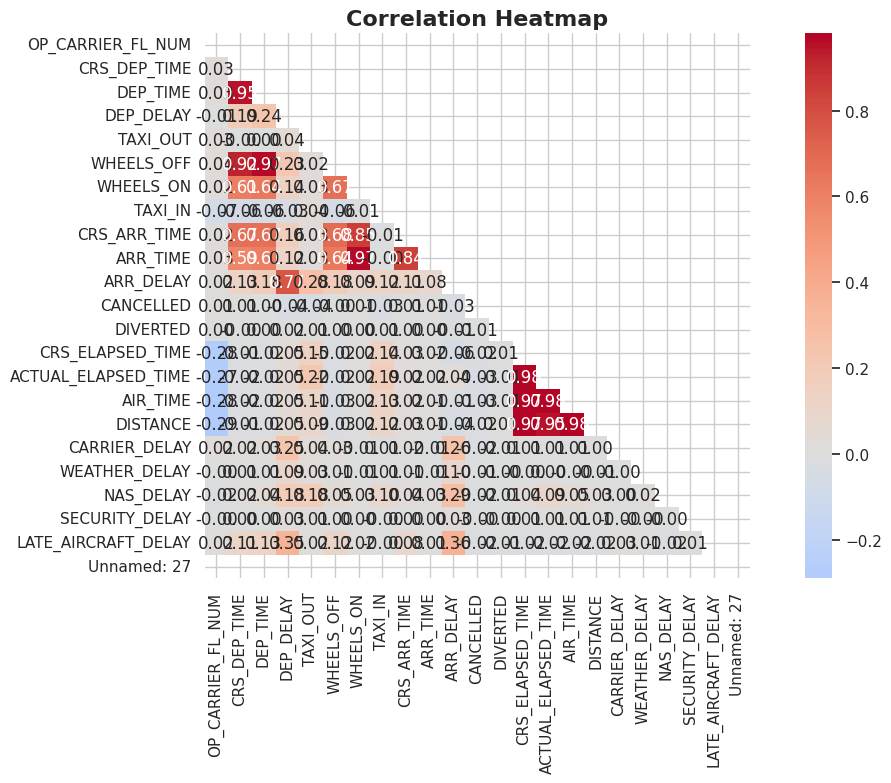

✓ Correlation heatmap created!

Top 5 Strongest Correlations:
------------------------------------------------------------
AIR_TIME ↔ DISTANCE: 0.980
CRS_ELAPSED_TIME ↔ ACTUAL_ELAPSED_TIME: 0.978
ACTUAL_ELAPSED_TIME ↔ AIR_TIME: 0.976
CRS_ELAPSED_TIME ↔ DISTANCE: 0.974
CRS_ELAPSED_TIME ↔ AIR_TIME: 0.971

Creating Scatter Plots...


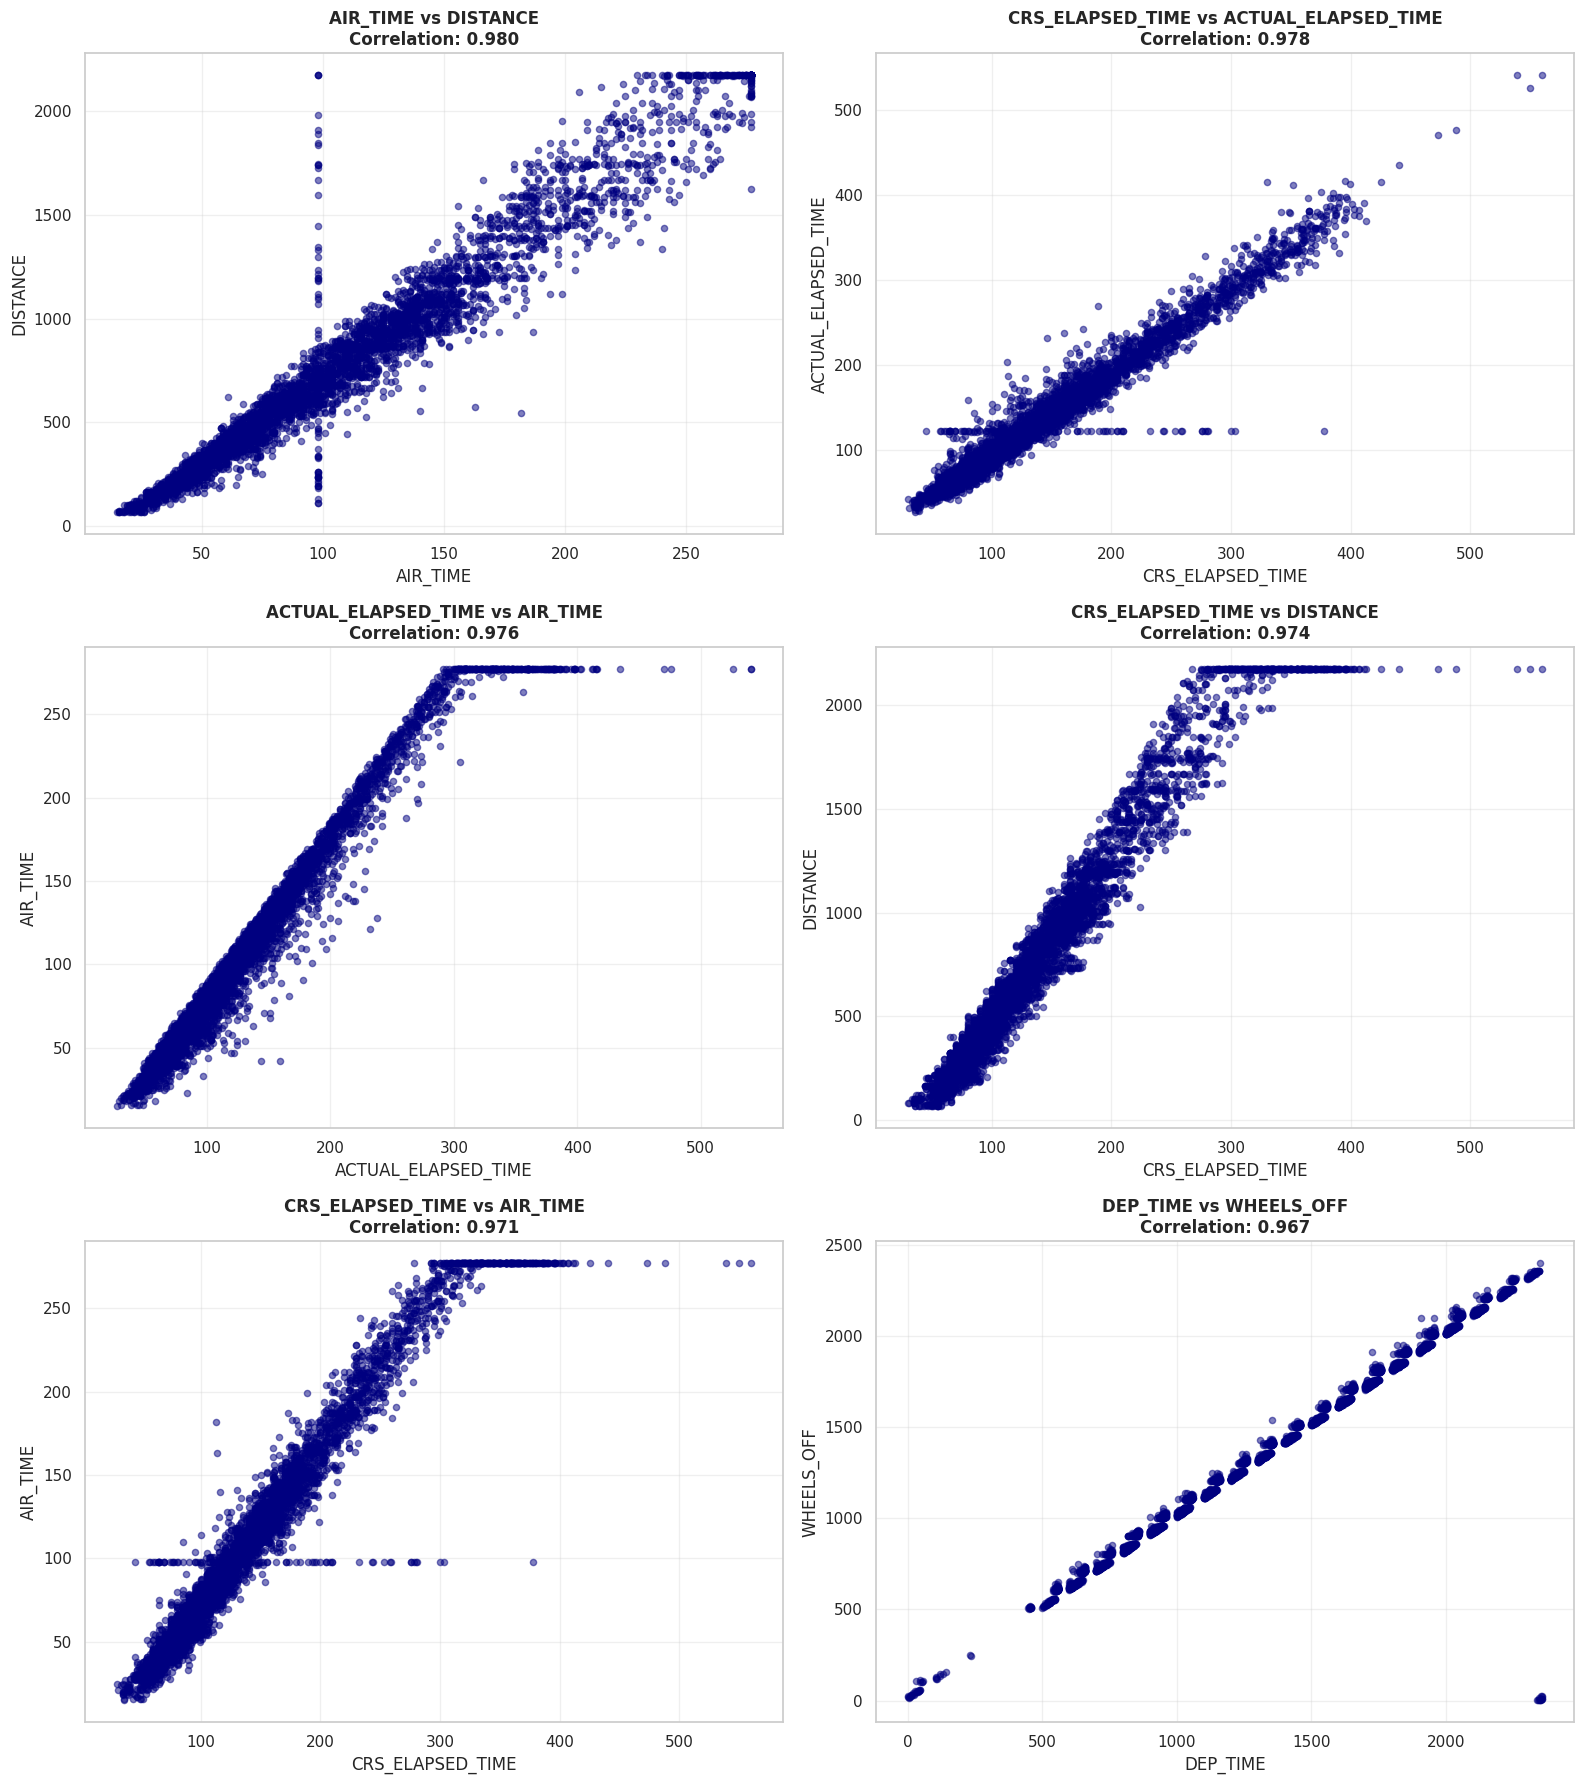

✓ Created 6 scatter plots!

✅ Bivariate Analysis Completed!


In [20]:
print("\nShape of Dataset:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing Values:\n", df.isnull().sum())
print("\nStatistical Summary:\n", df.describe())

num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()

print("\n" + "="*70)
print(f"Numerical Columns ({len(num_cols)}): {num_cols}")
print(f"Categorical Columns ({len(cat_cols)}): {cat_cols}")

print("UNIVARIATE ANALYSIS - NUMERICAL VARIABLES")

print("\nCreating Histograms...") #to show the distribution of each feature

# Calculate how many rows we need (3 plots per row)
n_rows = int(np.ceil(len(num_cols) / 3))

# Create a figure with multiple subplots
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5*n_rows))
axes = axes.ravel()  # Flatten to make it easier to use

# Create one histogram for each numerical column
for idx, col in enumerate(num_cols):
    # Plot histogram with a smooth curve (KDE)
    sns.histplot(df[col].dropna(), kde=True, ax=axes[idx], color='steelblue')

    # Add title and labels
    axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

    # Add mean and median lines for reference
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[idx].axvline(mean_val, color='red', linestyle='--',
                     label=f'Mean: {mean_val:.2f}')
    axes[idx].axvline(median_val, color='green', linestyle='--',
                     label=f'Median: {median_val:.2f}')
    axes[idx].legend()

# Hide extra empty plots
for idx in range(len(num_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()
print("✓ Histograms created!")

print("\nCreating Boxplots...")#to show distribution and identify outliers

# Create a figure with multiple subplots
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5*n_rows))
axes = axes.ravel()

# Create one boxplot for each numerical column
for idx, col in enumerate(num_cols):
    # Drop NaN values to avoid issues with plotting empty data
    plot_data = df[col].dropna()
    if plot_data.empty:
        # If no valid data, hide the axis and continue
        axes[idx].axis('off')
        print(f"  ⚠ Skipping boxplot for {col}: No valid data to plot after dropping NaNs.")
        continue

    # Plot boxplot
    sns.boxplot(x=plot_data, ax=axes[idx], color='coral')
    axes[idx].set_title(f'Boxplot of {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    q1 = plot_data.quantile(0.25)
    q3 = plot_data.quantile(0.75)
    median = plot_data.median()

    stats_text = f'Q1: {q1:.2f}\nMedian: {median:.2f}\nQ3: {q3:.2f}'
    axes[idx].text(0.02, 0.98, stats_text,
                  transform=axes[idx].transAxes,
                  verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
                  fontsize=9)

# Hide extra empty plots
for idx in range(len(num_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()
print("✓ Boxplots created!")

print("\n✅ Univariate Analysis Completed!")

print("BIVARIATE ANALYSIS")

if len(num_cols) > 1:

    print("\nCreating Correlation Heatmap...") #to show relationship with all features

    plt.figure(figsize=(12, 8))

    # Calculate correlation (how variables relate to each other)
    corr_matrix = df[num_cols].corr()

    # Create a mask to hide the upper triangle (removes duplicate info)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    # Create the heatmap
    # Red = positive correlation, Blue = negative correlation
    sns.heatmap(corr_matrix,
                mask=mask,
                annot=True,      # Show correlation values
                fmt='.2f',       # Format to 2 decimal places
                cmap='coolwarm', # Color scheme
                center=0,        # Center colors at 0
                square=True)     # Make cells square

    plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("✓ Correlation heatmap created!")

    # Print top correlations
    print("\nTop 5 Strongest Correlations:")
    print("-" * 60)

    # Extract all correlation pairs
    corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_pairs.append({
                'Variable_1': corr_matrix.columns[i],
                'Variable_2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

    # Sort by absolute correlation (strongest first)
    corr_df = pd.DataFrame(corr_pairs)
    corr_df['Abs_Corr'] = corr_df['Correlation'].abs()
    corr_df = corr_df.sort_values('Abs_Corr', ascending=False)

    # Show top 5
    for i, row in corr_df.head(5).iterrows():
        print(f"{row['Variable_1']} ↔ {row['Variable_2']}: {row['Correlation']:.3f}")


    print("\nCreating Scatter Plots...") #to show the relationship between pairs of features

    # Only create scatter plots for strong correlations (saves time and space)
    strong_corr = corr_df[corr_df['Abs_Corr'] > 0.5].head(6)

    if len(strong_corr) > 0:
        # Calculate how many plots we'll create
        n_plots = len(strong_corr)
        n_rows_scatter = int(np.ceil(n_plots / 2))

        # Create figure (2 plots per row)
        fig, axes = plt.subplots(n_rows_scatter, 2, figsize=(16, 6*n_rows_scatter))
        axes = axes.ravel()

        # Create scatter plot for each strong correlation
        for idx, (_, row) in enumerate(strong_corr.iterrows()):
            var1 = row['Variable_1']
            var2 = row['Variable_2']
            corr_val = row['Correlation']

            # Get data for these two variables
            plot_data = df[[var1, var2]].dropna()

            # If we have too much data, sample 5000 points (faster plotting)
            if len(plot_data) > 5000:
                plot_data = plot_data.sample(5000, random_state=42)

            # Create scatter plot
            axes[idx].scatter(plot_data[var1], plot_data[var2],
                            alpha=0.5, s=20, color='navy')
            axes[idx].set_title(f'{var1} vs {var2}\nCorrelation: {corr_val:.3f}',
                               fontweight='bold')
            axes[idx].set_xlabel(var1)
            axes[idx].set_ylabel(var2)
            axes[idx].grid(True, alpha=0.3)

        # Hide extra empty plots
        for idx in range(len(strong_corr), len(axes)):
            axes[idx].axis('off')

        plt.tight_layout()
        plt.show()
        print(f"✓ Created {len(strong_corr)} scatter plots!")

    else:
        print("⚠ No strong correlations found (threshold: 0.5)")
        print("  Creating scatter plots for top 4 pairs instead...")

        # If no strong correlations, just plot top 4
        top_pairs = corr_df.head(4)

        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        axes = axes.ravel()

        for idx, (_, row) in enumerate(top_pairs.iterrows()):
            var1 = row['Variable_1']
            var2 = row['Variable_2']
            corr_val = row['Correlation']

            plot_data = df[[var1, var2]].dropna()
            if len(plot_data) > 5000:
                plot_data = plot_data.sample(5000, random_state=42)

            axes[idx].scatter(plot_data[var1], plot_data[var2],
                            alpha=0.5, s=20, color='navy')
            axes[idx].set_title(f'{var1} vs {var2}\nCorrelation: {corr_val:.3f}',
                               fontweight='bold')
            axes[idx].set_xlabel(var1)
            axes[idx].set_ylabel(var2)
            axes[idx].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        print("✓ Scatter plots created!")
    print("\n✅ Bivariate Analysis Completed!")

else:
    print("\n⚠ Need at least 2 numerical columns for bivariate analysis.")

INITIAL STATISTICAL FINDINGS

 GENERATING INITIAL STATISTICAL FINDINGS 


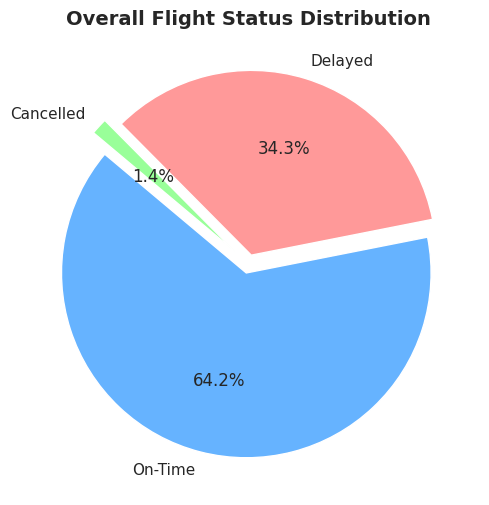

/tmp/ipython-input-184/677065878.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=airline_delays.index, y=airline_delays.values, ax=axes[0], palette='viridis')
/tmp/ipython-input-184/677065878.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=airport_delays.index, y=airport_delays.values, ax=axes[1], palette='magma')


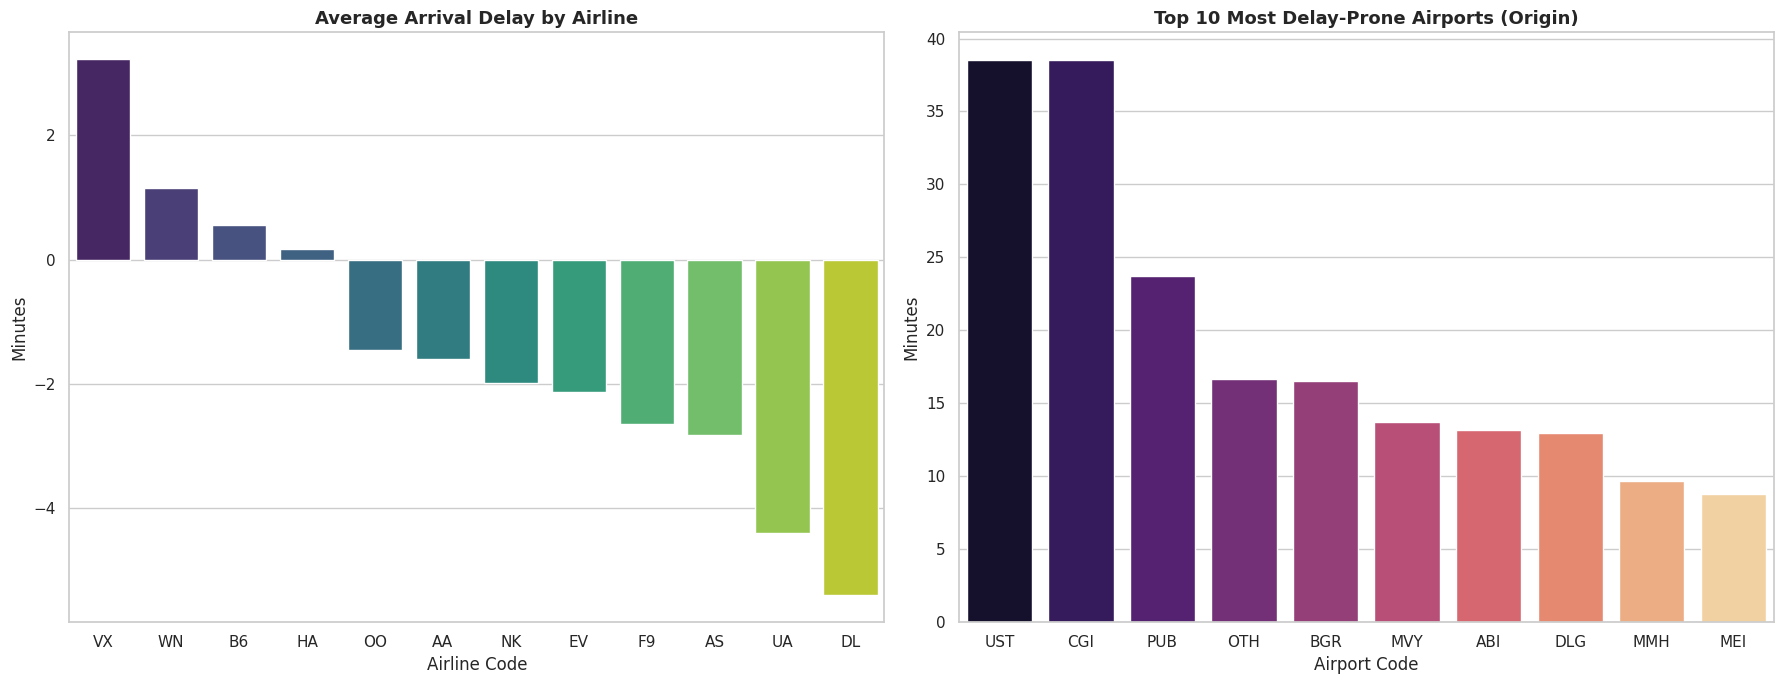

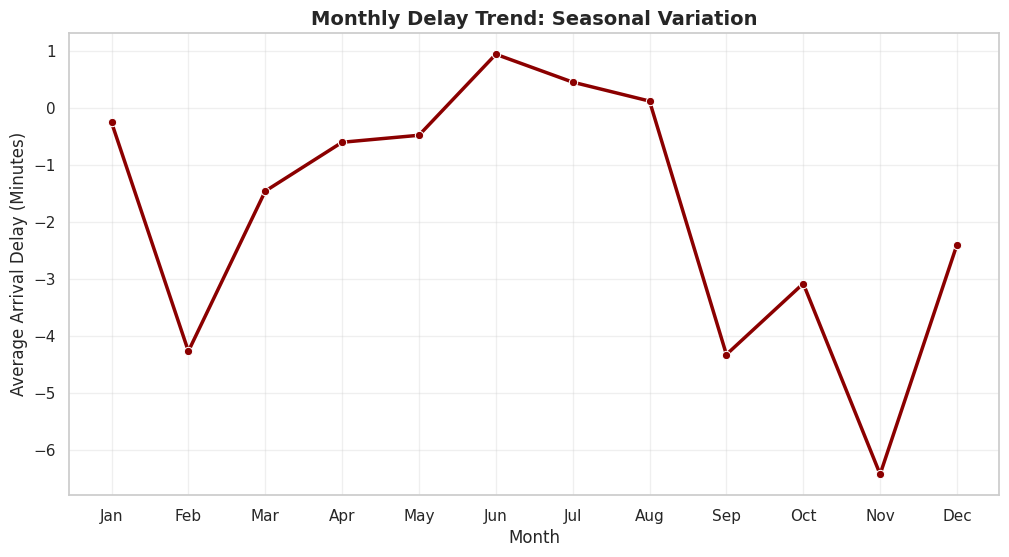

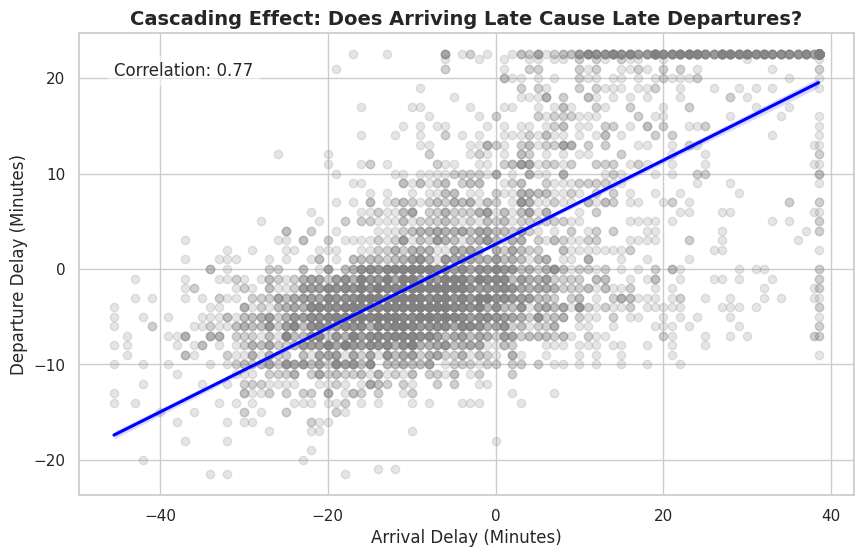


✓ Statistical Visualizations Complete!


In [21]:
sns.set_theme(style="whitegrid")

print(" GENERATING INITIAL STATISTICAL FINDINGS ")

# Defining status: Cancelled (1.0), Delayed (ARR_DELAY > 0), On-Time (ARR_DELAY <= 0)
cancelled_count = df['CANCELLED'].sum()
delayed_count = df[(df['CANCELLED'] == 0) & (df['ARR_DELAY'] > 0)].shape[0]
ontime_count = df[(df['CANCELLED'] == 0) & (df['ARR_DELAY'] <= 0)].shape[0]

labels = ['On-Time', 'Delayed', 'Cancelled']
sizes = [ontime_count, delayed_count, cancelled_count]
colors = ['#66b3ff', '#ff9999', '#99ff99'] # Soft blue, red, green

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.05, 0.05, 0.1))
plt.title('Overall Flight Status Distribution', fontsize=14, fontweight='bold')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Average Delay by Airline
airline_delays = df.groupby('OP_CARRIER')['ARR_DELAY'].mean().sort_values(ascending=False)
sns.barplot(x=airline_delays.index, y=airline_delays.values, ax=axes[0], palette='viridis')
axes[0].set_title('Average Arrival Delay by Airline', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Minutes')
axes[0].set_xlabel('Airline Code')

# Average Delay by Top 10 Airports
airport_delays = df.groupby('ORIGIN')['ARR_DELAY'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=airport_delays.index, y=airport_delays.values, ax=axes[1], palette='magma')
axes[1].set_title('Top 10 Most Delay-Prone Airports (Origin)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Minutes')
axes[1].set_xlabel('Airport Code')

plt.tight_layout()
plt.show()

df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
df['MONTH'] = df['FL_DATE'].dt.month

monthly_trend = df.groupby('MONTH')['ARR_DELAY'].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_trend.index, y=monthly_trend.values, marker='o', color='darkred', linewidth=2.5)
plt.title('Monthly Delay Trend: Seasonal Variation', fontsize=14, fontweight='bold')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.ylabel('Average Arrival Delay (Minutes)')
plt.xlabel('Month')
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(10, 6))
sns.regplot(x='ARR_DELAY', y='DEP_DELAY', data=df.sample(min(5000, len(df))),
            scatter_kws={'alpha':0.2, 'color':'gray'}, line_kws={'color':'blue'})

plt.title('Cascading Effect: Does Arriving Late Cause Late Departures?', fontsize=14, fontweight='bold')
plt.xlabel('Arrival Delay (Minutes)')
plt.ylabel('Departure Delay (Minutes)')

# Correlation Calculation
corr_val = df['ARR_DELAY'].corr(df['DEP_DELAY'])
plt.text(df['ARR_DELAY'].min(), df['DEP_DELAY'].max()*0.9, f'Correlation: {corr_val:.2f}',
         fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

plt.show()

print("\n✓ Statistical Visualizations Complete!")